# **Compound Data Acquisition and Bioactivity Filtering**

In this jupyter notebook, we collected bioactivity data for our target of interest from the **ChEMBL database**.
We filtered the data set in order to only contain molecules with measured IC50 bioactivity values.

**Goal: Get a list of compounds with bioactivity data for a given target**

* Connect to ChEMBL database
* Get target data (**example: MYC **)
    * Fetch and download target data
    * Select target ChEMBL ID
* Get bioactivity data
    * Fetch and download bioactivity data for targets
    * Preprocess and filter bioactivity data
* Get compound data
    * Fetch and download compound data
    * Preprocess and filter compound data
* Output bioactivity-compound data
    * Merge bioactivity and compound data, and add pIC50 values
    * Draw molecules with highest pIC50
    * Write output file

### **Data Retrieval Step**
This step consists of retrieving all compound data associated with the EGFR kinase from the ChEMBL database.

### Connect to ChEMBL database

In [1]:
pip install rdkit chembl_webresource_client


Note: you may need to restart the kernel to use updated packages.


 **Import Libraries**

In [2]:
import math
from pathlib import Path
import gdown
from zipfile import ZipFile
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
from rdkit.Chem import PandasTools
#from chembl_webresource_client.new_client import new_client
from tqdm.auto import tqdm

Failed to patch pandas - PandasTools will have limited functionality
/home/beyza/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from chembl_webresource_client.new_client import new_client

Create resource objects for API access.

In [4]:
targets_api = new_client.target
compounds_api = new_client.molecule
bioactivities_api = new_client.activity

In [5]:
type(targets_api)

chembl_webresource_client.query_set.QuerySet

### Get target data 

* Get UniProt ID of the target of interest (CTNNB1:  [P35222](http://www.uniprot.org/uniprot/P35222) and MYC: [P01106](http://www.uniprot.org/uniprot/P01106) ) from [UniProt website](https://www.uniprot.org/)
* Use UniProt ID to get target information

Select a different UniProt ID, if you are interested in another target.

In [6]:
uniprot_id = "P01106" # MYC

#### Fetch target data from ChEMBL

In [7]:
# Get target information from ChEMBL but restrict it to specified values only
targets = targets_api.get(target_components__accession=uniprot_id).only(
    "target_chembl_id", "organism", "pref_name", "target_type"
)
print(f'The type of the targets is "{type(targets)}"')

The type of the targets is "<class 'chembl_webresource_client.query_set.QuerySet'>"


#### Download target data from ChEMBL

In [8]:
targets = pd.DataFrame.from_records(targets)
targets

,organism,pref_name,target_chembl_id,target_type
0,Homo sapiens,Myc proto-oncogene protein,CHEMBL1250348,SINGLE PROTEIN
1,Homo sapiens,Myc proto-oncogene protein,CHEMBL1250348,SINGLE PROTEIN
2,Homo sapiens,c-Myc/Max,CHEMBL3301395,PROTEIN COMPLEX
3,Homo sapiens,c-Myc/c-Max,CHEMBL4106127,PROTEIN-PROTEIN INTERACTION
4,Homo sapiens,von Hippel-Lindau disease tumor suppressor/Myc...,CHEMBL4296141,PROTEIN-PROTEIN INTERACTION
5,Homo sapiens,MAP2K3/Myc proto-oncogene protein,CHEMBL4888452,PROTEIN-PROTEIN INTERACTION
6,Homo sapiens,Protein cereblon/Myc proto-oncogene protein,CHEMBL5465202,PROTEIN-PROTEIN INTERACTION
7,Homo sapiens,WDR5-MYC,CHEMBL5465553,PROTEIN-PROTEIN INTERACTION


#### Select target (target ChEMBL ID)

After checking the entries, we select the first entry as our target of interest:

In [9]:
target = targets.iloc[0]
target

organism                          Homo sapiens
pref_name           Myc proto-oncogene protein
target_chembl_id                 CHEMBL1250348
target_type                     SINGLE PROTEIN
Name: 0, dtype: str

In [10]:
#Save selected ChEMBL ID.
chembl_id = target.target_chembl_id
print(f"The target ChEMBL ID is {chembl_id}")

The target ChEMBL ID is CHEMBL1250348


### Bioactivity Data Acquisition
This stage involves querying the ChEMBL database to retrieve comprehensive bioactivity data associated with the selected target. The objective is to collect experimental results and measurements that define the interaction between small molecules and the EGFR kinase.

**Fetch bioactivity data for the target from ChEMBL** :
In this step, we fetch the bioactivity data and filter it to only consider:

* human proteins,
* bioactivity type IC50,
* exact measurements (relation `'='`), and
* binding data (assay type `'B'`)

In [11]:
bioactivities = bioactivities_api.filter(
    target_chembl_id=chembl_id, type="IC50", relation="=", assay_type="B"
).only(
    "activity_id",
    "assay_chembl_id",
    "assay_description",
    "assay_type",
    "molecule_chembl_id",
    "type",
    "standard_units",
    "relation",
    "standard_value",
    "target_chembl_id",
    "target_organism",
)

print(f"Length and type of bioactivities object: {len(bioactivities)}, {type(bioactivities)}")

Length and type of bioactivities object: 303, <class 'chembl_webresource_client.query_set.QuerySet'>


In [12]:
print(f"Length and type of first element: {len(bioactivities[0])}, {type(bioactivities[0])}")
bioactivities[0]

Length and type of first element: 13, <class 'dict'>


{'activity_id': 12625963,
 'assay_chembl_id': 'CHEMBL2318156',
 'assay_description': 'Inhibition of recombinant His6-tagged c-Myc bHLH-ZIP domain (353 to 437 amino acid residues) (unknown origin) assessed as disruption of Myc-Max dimerization by electrophoretic mobility shift assay',
 'assay_type': 'B',
 'molecule_chembl_id': 'CHEMBL1336889',
 'relation': '=',
 'standard_units': 'nM',
 'standard_value': '33000.0',
 'target_chembl_id': 'CHEMBL1250348',
 'target_organism': 'Homo sapiens',
 'type': 'IC50',
 'units': 'uM',
 'value': '33.0'}

#### Download bioactivity data from ChEMBL

The QuerySet is converted into a pandas DataFrame. If the download process takes too long or encounters issues, use the provided local **.csv** file as a backup to proceed with the analysis.

> **Note**: This step should not take more than 2 minutes, if so try to rerun all cells starting from _"Fetch bioactivity data for the target from ChEMBL"_ or read this message below:

<details>
    
<summary>Load a local version of the data (in case you encounter any problems while fetching the data)</summary>
    
If you experience difficulties to query the ChEMBL database, we also provide the resulting dataframe you will construct in the cell below. If you want to use the saved version, use the following code instead to obtain `bioactivities_df`:
  
```python
# replace first line in cell below with this other line 
bioactivities_df = pd.read_csv(DATA / "myc_bioactivities_raw.csv", index_col=0)
```

</details>

In [13]:
# Klasörü otomatik oluştur (yoksa yaratır, varsa dokunmaz)
Path("data").mkdir(exist_ok=True) 

In [ ]:
bioactivities_df = pd.DataFrame.from_dict(bioactivities)
# replace first line in cell below with this other line
#bioactivities_df =  pd.read_csv("data/myc_bioactivities_raw.csv", index_col=0)
print(f"DataFrame shape: {bioactivities_df.shape}")
bioactivities_df.head()

DataFrame shape: (303, 13)


,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type,units,value
0,12625963,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL1336889,=,nM,33000.0,CHEMBL1250348,Homo sapiens,IC50,uM,33.0
1,12625974,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL2312756,=,nM,146000.0,CHEMBL1250348,Homo sapiens,IC50,uM,146.0
2,12724301,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL165,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50,uM,60.0
3,12724334,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL1172104,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50,uM,60.0
4,14538606,CHEMBL3223392,Inhibition of c-MYC in human HL60 cells by che...,B,CHEMBL3222133,=,nM,29000.0,CHEMBL1250348,Homo sapiens,IC50,uM,29.0


In [15]:
bioactivities_df["units"].unique()

<StringArray>
['uM', 'nM']
Length: 2, dtype: str

In [16]:
bioactivities_df.drop(["units", "value"], axis=1, inplace=True)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type
0,12625963,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL1336889,=,nM,33000.0,CHEMBL1250348,Homo sapiens,IC50
1,12625974,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL2312756,=,nM,146000.0,CHEMBL1250348,Homo sapiens,IC50
2,12724301,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL165,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50
3,12724334,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL1172104,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50
4,14538606,CHEMBL3223392,Inhibition of c-MYC in human HL60 cells by che...,B,CHEMBL3222133,=,nM,29000.0,CHEMBL1250348,Homo sapiens,IC50


### Data Preprocessing and filtering bioactivity data

In [17]:
bioactivities_df.dtypes

activity_id           int64
assay_chembl_id         str
assay_description       str
assay_type              str
molecule_chembl_id      str
relation                str
standard_units          str
standard_value          str
target_chembl_id        str
target_organism         str
type                    str
dtype: object

In [18]:
bioactivities_df = bioactivities_df.astype({"standard_value": "float64"})
bioactivities_df.dtypes

activity_id             int64
assay_chembl_id           str
assay_description         str
assay_type                str
molecule_chembl_id        str
relation                  str
standard_units            str
standard_value        float64
target_chembl_id          str
target_organism           str
type                      str
dtype: object

**Delete entries with missing values**

In [19]:
bioactivities_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (303, 11)


**Keep only entries with "standard_unit == nM"**

In [20]:
print(f"Units in downloaded data: {bioactivities_df['standard_units'].unique()}")
print(
    f"Number of non-nM entries:\
    {bioactivities_df[bioactivities_df['standard_units'] != 'nM'].shape[0]}"
)


Units in downloaded data: <StringArray>
['nM']
Length: 1, dtype: str
Number of non-nM entries:    0


In [21]:
bioactivities_df = bioactivities_df[bioactivities_df["standard_units"] == "nM"]
print(f"Units after filtering: {bioactivities_df['standard_units'].unique()}")

Units after filtering: <StringArray>
['nM']
Length: 1, dtype: str


In [22]:
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (303, 11)


**Delete duplicate molecules**

In [23]:
bioactivities_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (301, 11)


**Reset "DataFrame" index**

In [24]:
bioactivities_df.reset_index(drop=True, inplace=True)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type
0,12625963,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL1336889,=,nM,33000.0,CHEMBL1250348,Homo sapiens,IC50
1,12625974,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL2312756,=,nM,146000.0,CHEMBL1250348,Homo sapiens,IC50
2,12724301,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL165,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50
3,12724334,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL1172104,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50
4,14538606,CHEMBL3223392,Inhibition of c-MYC in human HL60 cells by che...,B,CHEMBL3222133,=,nM,29000.0,CHEMBL1250348,Homo sapiens,IC50


**Rename columns**

In [25]:
bioactivities_df.rename(
    columns={"standard_value": "IC50", "standard_units": "units"}, inplace=True
)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,units,IC50,target_chembl_id,target_organism,type
0,12625963,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL1336889,=,nM,33000.0,CHEMBL1250348,Homo sapiens,IC50
1,12625974,CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,CHEMBL2312756,=,nM,146000.0,CHEMBL1250348,Homo sapiens,IC50
2,12724301,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL165,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50
3,12724334,CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,CHEMBL1172104,=,nM,60000.0,CHEMBL1250348,Homo sapiens,IC50
4,14538606,CHEMBL3223392,Inhibition of c-MYC in human HL60 cells by che...,B,CHEMBL3222133,=,nM,29000.0,CHEMBL1250348,Homo sapiens,IC50


In [26]:
print(f"DataFrame shape: {bioactivities_df.shape}")


DataFrame shape: (301, 11)


We now have a set of **301** molecule ids with respective IC50 values for our target MYC .(**83** molecule ids with respective IC50 values for our target CTNNB1) .--> We have a `DataFrame` containing all molecules tested against MYC (with the respective measured bioactivity).

### Molecular Structure Retrieval
Now, we want to get the molecular structures of the molecules that are linked to respective bioactivity ChEMBL IDs.

#### Fetch compound data from ChEMBL

In [27]:
compounds_provider = compounds_api.filter(
    molecule_chembl_id__in=list(bioactivities_df["molecule_chembl_id"])
).only("molecule_chembl_id", "molecule_structures")

#### Download compound data from ChEMBL

In [28]:
compounds = list(tqdm(compounds_provider))

100%|██████████| 301/301 [00:00<00:00, 7796.49it/s]


In [29]:
compounds_df = pd.DataFrame.from_records(
    compounds,
)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (301, 2)


In [30]:
compounds_df.head()

,molecule_chembl_id,molecule_structures
0,CHEMBL686,{'canonical_smiles': 'Cc1cccc(Nc2ccccc2C(=O)O)...
1,CHEMBL165,{'canonical_smiles': 'Oc1ccc(/C=C/c2cc(O)cc(O)...
2,CHEMBL212723,{'canonical_smiles': 'Cc1ccc(C)n1-c1ccc(C(=O)O...
3,CHEMBL213432,{'canonical_smiles': 'Cc1ccc(C)n1-c1cccc(C(=O)...
4,CHEMBL212827,{'canonical_smiles': 'Cc1ccc(C)n1-c1ccc(C(=O)O...


#### Preprocess and filter compound data

**Remove entries with missing molecule structure entry**

In [31]:
compounds_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (301, 2)


**Delete duplicate molecules**

In [32]:
compounds_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (301, 2)


**Get molecules with canonical SMILES**

In [33]:
compounds_df.iloc[0].molecule_structures.keys()

dict_keys(['canonical_smiles', 'molfile', 'standard_inchi', 'standard_inchi_key'])

In [34]:
canonical_smiles = []

for i, compounds in compounds_df.iterrows():
    try:
        canonical_smiles.append(compounds["molecule_structures"]["canonical_smiles"])
    except KeyError:
        canonical_smiles.append(None)

compounds_df["smiles"] = canonical_smiles
compounds_df.drop("molecule_structures", axis=1, inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (301, 2)


In [35]:
compounds_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (301, 2)


# Summary of compound and bioactivity data

In [36]:
print(f"Bioactivities filtered: {bioactivities_df.shape[0]}")
bioactivities_df.columns

Bioactivities filtered: 301


Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'molecule_chembl_id', 'relation', 'units', 'IC50', 'target_chembl_id',
       'target_organism', 'type'],
      dtype='str')

In [37]:
print(f"Compounds filtered: {compounds_df.shape[0]}")
compounds_df.columns

Compounds filtered: 301


Index(['molecule_chembl_id', 'smiles'], dtype='str')

### **Merge both datasets**

Merge values of interest from `bioactivities_df` and `compounds_df` in an `output_df`, keeping the following columns:

* ChEMBL IDs: `molecule_chembl_id`
* SMILES: `smiles`
* units: `units`
* IC50: `IC50`

In [38]:
# Merge DataFrames
output_df = pd.merge(
    bioactivities_df[["molecule_chembl_id", "IC50", "units"]],
    compounds_df,
    on="molecule_chembl_id",
)

# Reset row indices
output_df.reset_index(drop=True, inplace=True)

print(f"Dataset with {output_df.shape[0]} entries.")

Dataset with 301 entries.


In [39]:
output_df.dtypes

molecule_chembl_id        str
IC50                  float64
units                     str
smiles                    str
dtype: object

In [40]:
output_df.head(10)

,molecule_chembl_id,IC50,units,smiles
0,CHEMBL1336889,33000.0,nM,O=C(O)c1ccc(Nc2ccc([N+](=O)[O-])c3nonc23)cc1
1,CHEMBL2312756,146000.0,nM,O=[N+]([O-])c1ccc(Nc2ccccc2-c2ccccc2)c2nonc12
2,CHEMBL165,60000.0,nM,Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1
3,CHEMBL1172104,60000.0,nM,COc1cc(/C=C\c2ccc(OC)c(OC)c2)cc(OC)c1
4,CHEMBL3222133,29000.0,nM,CC(C)c1ccc(/C=C2\SC(=S)N(CN3CCCCC3)C2=O)cc1
5,CHEMBL4248559,7000.0,nM,N#Cc1ccc(-c2cc(-c3ccc(C(N)=O)cc3)nc(-c3ccco3)n...
6,CHEMBL4243533,10000.0,nM,N#Cc1cc(-c2ccc(C(N)=O)cc2)ccn1
7,CHEMBL4246868,10000.0,nM,CS(=O)(=O)NC(=O)c1ccc(-c2cc(-c3ccc(C#N)cc3)nc(...
8,CHEMBL4243878,2000.0,nM,N#Cc1ccc(-c2cc(-c3ccc(-c4nnn[nH]4)cc3)cc(-c3cc...
9,CHEMBL4240109,5000.0,nM,N#Cc1ccc(-c2cc(-c3ccccc3)cc(-c3ccco3)n2)cc1


## **convert the IC50 values to pIC50**

In [41]:
def convert_ic50_to_pic50(IC50_value):
    pIC50_value = 9 - math.log10(IC50_value)
    return pIC50_value

In [42]:
# Apply conversion to each row of the compounds DataFrame
output_df["pIC50"] = output_df.apply(lambda x: convert_ic50_to_pic50(x.IC50), axis=1)

In [43]:
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL1336889,33000.0,nM,O=C(O)c1ccc(Nc2ccc([N+](=O)[O-])c3nonc23)cc1,4.481486
1,CHEMBL2312756,146000.0,nM,O=[N+]([O-])c1ccc(Nc2ccccc2-c2ccccc2)c2nonc12,3.835647
2,CHEMBL165,60000.0,nM,Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1,4.221849
3,CHEMBL1172104,60000.0,nM,COc1cc(/C=C\c2ccc(OC)c(OC)c2)cc(OC)c1,4.221849
4,CHEMBL3222133,29000.0,nM,CC(C)c1ccc(/C=C2\SC(=S)N(CN3CCCCC3)C2=O)cc1,4.537602


# pIC50 value distribution

array([[<Axes: title={'center': 'pIC50'}>]], dtype=object)

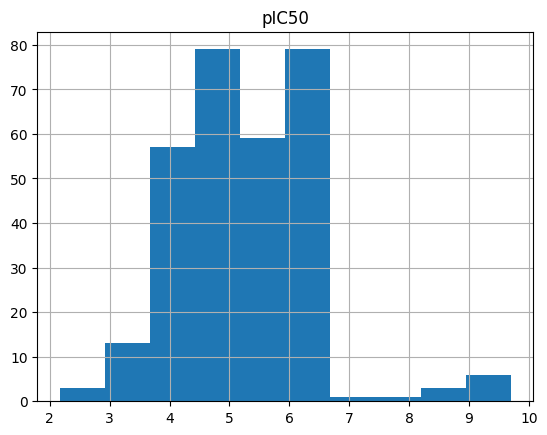

In [44]:
output_df.hist(column="pIC50")

Look at the structures of the molecules with the highest pIC50 values:

In [45]:
# Add molecule column
PandasTools.AddMoleculeColumnToFrame(output_df, smilesCol="smiles")

Failed to patch pandas - unable to change molecule rendering


In [46]:
# Sort molecules by pIC50
output_df.sort_values(by="pIC50", ascending=False, inplace=True)

# Reset index
output_df.reset_index(drop=True, inplace=True)

**Three most active molecules**, with the highest pIC50 values:

In [47]:
output_df.drop("smiles", axis=1).head(3)

,molecule_chembl_id,IC50,units,pIC50,ROMol
0,CHEMBL5089688,0.2,nM,9.698970,<rdkit.Chem.rdchem.Mol object at 0x73e019f36340>
1,CHEMBL5084636,0.6,nM,9.221849,<rdkit.Chem.rdchem.Mol object at 0x73e019f36490>
2,CHEMBL5075294,0.7,nM,9.154902,<rdkit.Chem.rdchem.Mol object at 0x73e019f36730>


In [48]:
# Prepare saving the dataset: Drop the ROMol column
output_df = output_df.drop("ROMol", axis=1)
print(f"DataFrame shape: {output_df.shape}")

DataFrame shape: (301, 5)


#### Write output data to csv file

In [ ]:
# output_path = Path("data") / "myc_compounds_chembl.csv"
# output_df.to_csv(output_path, index=False)

In [50]:
print(f"DataFrame shape: {output_df.shape}")


DataFrame shape: (301, 5)


In [51]:
display(output_df.head())

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL5089688,0.2,nM,Cc1nnn(C)c1-c1ccc2c3ncc(C(C)(C)O)cc3n([C@H](c3...,9.698970
1,CHEMBL5084636,0.6,nM,Cc1nnn(C)c1-c1ccc2c3ncc(C(C)(C)O)cc3n([C@H](c3...,9.221849
2,CHEMBL5075294,0.7,nM,[2H]C([2H])([2H])c1nnn(C)c1-c1cc2c(cc1F)c1ncc(...,9.154902
3,CHEMBL4297458,0.7,nM,Cc1nnn(C)c1-c1cnc2c3ccc(C(C)(C)O)cc3n([C@H](c3...,9.154902
4,CHEMBL5086429,0.8,nM,Cc1nnn(C)c1-c1cc2c(cc1F)c1ncc(C(C)(C)O)cc1n2[C...,9.096910
